## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Claire Curzan

**Date:** 9/30/2026

338
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64
height
0.181818    30
0.545455    30
0.636364    30
0.454545    29
0.727273    29
0.818182    29
0.363636    

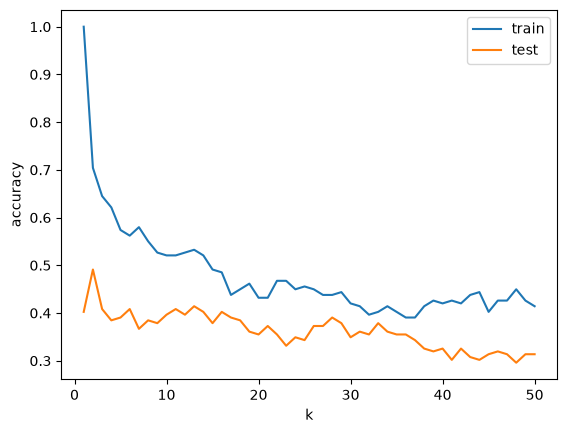

col_0       1   2   3  4  5
mine_type                  
1          28   0   9  1  0
2           0  29   3  1  2
3           8   0  15  5  5
4          13   2  11  9  0
5          10   0  12  4  2
accuracy: 0.4911242603550296


In [9]:
# Your Phase 1 solution to the problem goes here.

### Q1 ###

# 1) The difference between regression and classification is the kind of target being predicted. Regression predicts a numeric outcome, 
# like baseline sales, and classification predicts a category, like class. In kNN specifically, the only difference is in the last step:
# for regression you average the outcomes of the k nearest neighbors, and for classification you predict the most common class among them.

# 2) A confusion table is a table that counts predictions by actual class and predicted class, with rows as the actual classes and columns as
# the predictions. The diagonal cells are the correct predictions and the off-diagonal cells are the misclassifications. It helps us understand
# which classes the model gets wrong and what it confuses them with (false positives vs false negatives).

# 3) The SSE quantifies the total size of a model's prediction errors. The residual for an observation is the actual value minus the predicted
# value, and the SSE squares all the residuals and adds them up. A lower SSE on the validation set means the model makes smaller errors on that
# set.

# 4) Overfitting is when the model fits the noise in the training data, so it does well on the training data but badly on new data. Overfitting
# happens when k is very small. Underfitting is when the model is too simple to pick up real differences between observations. Underfitting 
# happens when k is very large, because averaging that many neighbors gives nearly the same prediction for everything.

# 5) Splitting the data into training and testing sets and choosing k on the test set improves model performance because what we care about is
# generalization (how well the model predicts data that was not used to fit it). If you choose k by training error alone, you would pick a
# very small k, since the predictions follow the training data closely, and that overfits. Evaluating on the test set estimates how the model
# will do on future data. Picking the k with the lowest SSE (or highest accuracy) there avoids both a k that is too small, which overfits,
# and a k that is too large, which underfits. The best k depends on which observations randomly end up in the training and test sets, so a
# different split could give a different best k.

# 6) With classification, kNN can report a class label by predicting the most common class among the neighbors, or a probability distribution 
# by dividing each class's neighbor count by k.
#         Class Label: The strength of reporting a class label is that it is simple and gives one clear answer to act on, and it is easy to
#           evaluate with accuracy and a confusion table. The weakness is that it hides how sure the model is. With k = 5, a 3 to 2 vote and a 
#           5 to 0 vote give the same label.
#
#         Probability Distribution: The strength of reporting a probability distribution is that it shows how confident the model is and what
#           the second most likely class is. That matters when false positives and false negatives have different costs, because the user can
#           choose their own cutoff. The weaknesses are that it is harder to read and evaluate, and someone still has to turn it into a decision.
#           With a small k the proportions are also very rough (with k = 3 they can only be 0, 1/3, 2/3 or 1).

### Q2 ###

# 1)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

mine_df = pd.read_csv("./data/land_mines.csv")
print(len(mine_df))
print(mine_df.head())
print(mine_df.describe())

# target label
print(mine_df["mine_type"].value_counts())

# features
print(mine_df["soil"].value_counts())
print(mine_df["height"].value_counts())

# average of each feature by mine type
print(mine_df.groupby("mine_type")[["voltage", "height", "soil"]].mean())

# Summary of the EDA for 2.1:
# There are 338 rows and no missing values. The target (mine_type) takes values 1 to 5 and the classes are balanced (65 to 71 each).
# The three features all range from about 0 to 1. voltage is skewed right (mean 0.43, median 0.36), height takes 12 different values, and
# soil takes 6 values that each show up about equally.
# Type 2 has a much higher average voltage (0.72) than the others, and type 1 has the lowest (0.30). Types 3, 4 and 5 are close together
# (0.35 to 0.40), and height and soil averages are about the same for every type, so I expect types 3, 4 and 5 to be hard to tell apart.

# 2) Split 50/50 so 169 training and 169 test set
X = mine_df[["voltage", "height", "soil"]]
y = mine_df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=100
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3)
ks = np.arange(1, 51)
test_acc = []
train_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_scaled, y_train)
    test_hat = model.predict(X_test_scaled)
    train_hat = model.predict(X_train_scaled)
    test_acc.append(np.sum(test_hat == y_test) / len(y_test))
    train_acc.append(np.sum(train_hat == y_train) / len(y_train))

k_star = int(ks[np.argmax(test_acc)])
print("best k:", k_star)
print("test accuracy at best k:", max(test_acc))

plt.plot(ks, train_acc, label="train")
plt.plot(ks, test_acc, label="test")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.legend()
plt.show()

# How I select k: 
# I tried every k from 1 to 50. For each one, I fit the model on the training set and checked how accurate it was on the
# test set. Then I picked the k with the highest test accuracy, which was k = 2 (about 0.49). I used the test accuracy and not the training
# accuracy because the training accuracy is always best when k is tiny. At k = 1 the training accuracy is 1.0 but the test accuracy is only 
# about 0.40, so the model is overfitting. When k gets big the test accuracy drops to around 0.30, so the model is underfitting.

# 4)
best_model = KNeighborsClassifier(n_neighbors=k_star)
best_model.fit(X_train_scaled, y_train)
y_hat = best_model.predict(X_test_scaled)

print(pd.crosstab(y_test, y_hat))

accuracy = np.sum(y_hat == y_test) / len(y_test)
print("accuracy:", accuracy)

# Answers to questions in 4:
# How accurate is it? The diagonal cells are the correct predictions, and they add up to 28 + 29 + 15 + 9 + 2 = 83 out of 169 test
# observations, so the accuracy is 83/169 = 0.49. That is better than random guessing, which would be about 0.20 with 5 balanced classes, 
# but my model is still wrong about half the time.

# Where is performance more accurate? Performance is most accurate for type 2, where 29 of the 35 actual type 2 mines are predicted correctly
# (83%). This makes sense because type 2 has a much higher average voltage than the other types, so its neighbors are mostly other type 2 mines.
# Type 1 is next, with 28 of 38 correct (74%).

# Where is performance less accurate? Performance is less accurate for types 3, 4 and 5. Type 3 is 15 of 33 correct (45%), type 4 is 9 of 35 
# (26%), and type 5 is the worst at 2 of 28 (7%). My model only predicts type 5 nine times in total. Most of the actual type 4 and type 5 mines
# get predicted as type 1 or type 3. This matches the EDA, where types 3, 4 and 5 had almost the same average voltage, height and soil, so their
# nearest neighbors are a mix of classes.

# 5)
# I'd advise someone to use this predictive model as a first guess, not a final answer, because of the errors it tends to make. The model catches
# 28 of the 38 actual type 1 mines, which looks accurate, but it predicted type 1 a total of 59 times and was only right on 28 of those (47%).
# So, it gets a lot of type 1 mines correct mostly because it predicts that label so often, and the same thing happens with type 3 (15 right out
# of 50 predictions).

# Given that, I'd advise them to mostly trust a prediction of type 2, since 29 of the 31 type 2 predictions were correct (94%). A prediction of
# type 1 or type 3 should not be treated as confirmed, because a lot of type 4 and type 5 mines get mislabeled as those. My model misses almost
# all of the type 5 mines, so the crew should still handle every mine carefully and plan for the most dangerous type it could be, since a wrong
# call could get someone hurt.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]